In [34]:
import pandas as pd
import numpy as np
import warnings
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, roc_curve, auc, confusion_matrix, 
                             precision_recall_curve, f1_score, precision_score, recall_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

In [ ]:
global_data = None
global_X_train = None
global_X_test = None
global_y_train = None
global_y_test = None
global_X_train_scaled = None
global_X_test_scaled = None
global_scaler = None
global_imputer = None
global_models = {}
global_predictions = {}
global_results = {}
global_ensemble_predictions = {}  # ДЛЯ ENSEMBLE
global_ensemble_results = {}  # ДЛЯ ENSEMBLE



In [61]:
CONFIG = {
    'data_path': 'D:/my_ML/diploma_polytech/data/raw/vehicle_ins_data_1.csv',
    'test_size': 0.2,
    'random_state': 42,
    'cv_folds': 5,
    'reference_date': '2019-12-31',
    'n_estimators': 500,
    'max_depth': 5,
    'learning_rate': 0.1,
}

In [59]:
def cell_1_load_data():
    """
    ЯЧЕЙКА 1: Загрузка данных из файла
    Запуск: cell_1_load_data()
    """
    global global_data
    
    print("="*70)
    print("ЯЧЕЙКА 1: ЗАГРУЗКА ДАННЫХ")
    print("="*70)
    
    global_data = pd.read_csv(CONFIG['data_path'], sep=";", index_col=False)
    print(f"✓ Данные загружены. Форма: {global_data.shape}")
    print(f"✓ Столбцы: {list(global_data.columns)}")
    print(f"\nПримеры данных:")
    print(global_data.head())
    print(f"\nИнформация о типах данных:")
    print(global_data.dtypes)
    return global_data

In [60]:
def cell_2_preprocess_data():
    """
    ЯЧЕЙКА 2: Предобработка и инженерия признаков
    Требует: cell_1_load_data()
    Запуск: cell_2_preprocess_data()
    """
    global global_data, global_imputer
    
    if global_data is None:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 1!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 2: ПРЕДОБРАБОТКА И ИНЖЕНЕРИЯ ПРИЗНАКОВ")
    print("="*70)
    
    # Создание целевой переменной
    global_data['claim_prob'] = (global_data['N_claims_year'] > 1).astype(int)
    print(f"✓ Целевая переменная создана")
    print(f"  Распределение: 0 - {(global_data['claim_prob'] == 0).sum()}, "
          f"1 - {(global_data['claim_prob'] == 1).sum()}")
    
    # Удаление ненужных столбцов
    cols_to_drop = ['ID', 'Date_last_renewal', 'Date_next_renewal', 
                    'Date_lapse', 'N_claims_year', 'Cost_claims_year', 
                    'N_claims_history', 'Value_vehicle', 'Payment', 
                    'R_Claims_history', 'Max_products', 'Cylinder_capacity', 
                    'N_doors', 'Type_fuel', 'Length', 'Weight']
    global_data = global_data.drop(columns=[col for col in cols_to_drop if col in global_data.columns])
    print(f"✓ Удалены {len(cols_to_drop)} столбцов")
    
    # Обработка датовых колонок
    date_columns = ['Date_birth', 'Date_driving_licence', 'Date_start_contract']
    reference_date = pd.to_datetime(CONFIG['reference_date'])
    
    existing_date_columns = [col for col in date_columns if col in global_data.columns]
    print(f"✓ Обнаружены датовые колонки: {existing_date_columns}")
    
    for col in existing_date_columns:
        global_data[col] = pd.to_datetime(global_data[col], format='%d/%m/%Y', errors='coerce')
    
    # Извлечение числовых признаков из дат
    if 'Date_birth' in global_data.columns:
        global_data['Age'] = (reference_date - global_data['Date_birth']).dt.days // 365
        print(f"✓ Извлечен признак Age (возраст)")
    
    if 'Date_driving_licence' in global_data.columns:
        global_data['Driving_experience'] = (reference_date - global_data['Date_driving_licence']).dt.days // 365
        print(f"✓ Извлечен признак Driving_experience (опыт вождения)")
    
    if 'Date_start_contract' in global_data.columns:
        global_data['Contract_age'] = (reference_date - global_data['Date_start_contract']).dt.days // 365
        print(f"✓ Извлечен признак Contract_age (возраст контракта)")
    
    # Удаление исходных датовых колонок
    global_data = global_data.drop(columns=existing_date_columns, errors='ignore')
    
    # Преобразование в числовой тип
    global_data = global_data.apply(pd.to_numeric, errors='coerce')
    
    # Обработка пропущенных значений
    global_imputer = SimpleImputer(strategy='median')
    data_imputed = global_imputer.fit_transform(global_data)
    global_data = pd.DataFrame(data_imputed, columns=global_data.columns)
    print(f"✓ Пропущенные значения обработаны")
    print(f"✓ Финальная форма данных: {global_data.shape}")
    print(f"\nОставшиеся признаки ({global_data.shape[1]}):")
    print(list(global_data.columns))
    
    return global_data

In [62]:
def cell_3_split_data():
    """
    ЯЧЕЙКА 3: Разделение данных на train/test и нормализация
    Требует: cell_2_preprocess_data()
    Запуск: cell_3_split_data()
    """
    global global_data, global_X_train, global_X_test, global_y_train, global_y_test
    global global_X_train_scaled, global_X_test_scaled, global_scaler
    
    if global_data is None:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 2!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 3: РАЗДЕЛЕНИЕ И НОРМАЛИЗАЦИЯ ДАННЫХ")
    print("="*70)
    
    X = global_data.drop(columns=['claim_prob'])
    y = global_data['claim_prob']
    
    global_X_train, global_X_test, global_y_train, global_y_test = train_test_split(
        X, y, test_size=CONFIG['test_size'], 
        random_state=CONFIG['random_state'], stratify=y
    )
    
    # Нормализация
    global_scaler = StandardScaler()
    global_X_train_scaled = global_scaler.fit_transform(global_X_train)
    global_X_test_scaled = global_scaler.transform(global_X_test)
    
    print(f"✓ Train размер: {global_X_train.shape}")
    print(f"✓ Test размер: {global_X_test.shape}")
    print(f"✓ Train баланс классов: 0 - {(global_y_train == 0).sum()}, "
          f"1 - {(global_y_train == 1).sum()}")
    print(f"✓ Test баланс классов: 0 - {(global_y_test == 0).sum()}, "
          f"1 - {(global_y_test == 1).sum()}")
    
    return (global_X_train, global_X_test, global_y_train, global_y_test, 
            global_X_train_scaled, global_X_test_scaled)

In [63]:
def cell_4a_train_logistic_regression():
    """
    ЯЧЕЙКА 4A: Обучение Logistic Regression
    Требует: cell_3_split_data()
    Запуск: cell_4a_train_logistic_regression()
    """
    global global_X_train_scaled, global_y_train, global_models
    
    if global_X_train_scaled is None:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 3!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 4A: ОБУЧЕНИЕ LOGISTIC REGRESSION")
    print("="*70)
    
    print("\n[1/5] Logistic Regression...")
    lr = LogisticRegression(max_iter=1000, random_state=CONFIG['random_state'], 
                           class_weight='balanced')
    lr.fit(global_X_train_scaled, global_y_train)
    global_models['Logistic Regression'] = lr
    print("✓ Модель Logistic Regression обучена и сохранена")
    print(f"✓ Количество обученных моделей: {len(global_models)}")

    return lr

In [64]:
def cell_4b_train_random_forest():
    """
    ЯЧЕЙКА 4B: Обучение Random Forest
    Требует: cell_3_split_data()
    Запуск: cell_4b_train_random_forest()
    """
    global global_X_train, global_y_train, global_models
    
    if global_X_train is None:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 3!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 4B: ОБУЧЕНИЕ RANDOM FOREST")
    print("="*70)
    
    print("\n[2/5] Random Forest...")
    rf = RandomForestClassifier(n_estimators=CONFIG['n_estimators'], 
                               max_depth=CONFIG['max_depth'],
                               random_state=CONFIG['random_state'],
                               class_weight='balanced', n_jobs=-1)
    rf.fit(global_X_train, global_y_train)
    global_models['Random Forest'] = rf
    print("✓ Модель Random Forest обучена и сохранена")
    print(f"✓ Количество обученных моделей: {len(global_models)}")
    
    return rf

In [65]:
def cell_4c_train_gradient_boosting():
    """
    ЯЧЕЙКА 4C: Обучение Gradient Boosting
    Требует: cell_3_split_data()
    Запуск: cell_4c_train_gradient_boosting()
    """
    global global_X_train, global_y_train, global_models
    
    if global_X_train is None:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 3!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 4C: ОБУЧЕНИЕ GRADIENT BOOSTING")
    print("="*70)
    
    print("\n[3/5] Gradient Boosting...")
    gb = GradientBoostingClassifier(n_estimators=CONFIG['n_estimators'],
                                   max_depth=CONFIG['max_depth'],
                                   learning_rate=CONFIG['learning_rate'],
                                   random_state=CONFIG['random_state'])
    gb.fit(global_X_train, global_y_train)
    global_models['Gradient Boosting'] = gb
    print("✓ Модель Gradient Boosting обучена и сохранена")
    print(f"✓ Количество обученных моделей: {len(global_models)}")
    
    return gb

In [66]:
def cell_4d_train_xgboost():
    """
    ЯЧЕЙКА 4D: Обучение XGBoost
    Требует: cell_3_split_data()
    Запуск: cell_4d_train_xgboost()
    """
    global global_X_train, global_X_test, global_y_train, global_y_test, global_models
    
    if global_X_train is None:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 3!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 4D: ОБУЧЕНИЕ XGBOOST")
    print("="*70)
    
    pos_weight = len(global_y_train[global_y_train == 0]) / len(global_y_train[global_y_train == 1])
    
    print("\n[4/5] XGBoost...")
    xgb = XGBClassifier(n_estimators=CONFIG['n_estimators'],
                       max_depth=CONFIG['max_depth'],
                       learning_rate=CONFIG['learning_rate'],
                       random_state=CONFIG['random_state'],
                       scale_pos_weight=pos_weight,
                       verbosity=0)
    xgb.fit(global_X_train, global_y_train, eval_set=[(global_X_test, global_y_test)], 
           verbose=False)
    global_models['XGBoost'] = xgb
    print("✓ Модель XGBoost обучена и сохранена")
    print(f"✓ Количество обученных моделей: {len(global_models)}")
    
    return xgb

In [67]:
def cell_4e_train_catboost():
    """
    ЯЧЕЙКА 4E: Обучение CatBoost
    Требует: cell_3_split_data()
    Запуск: cell_4e_train_catboost()
    """
    global global_X_train, global_y_train, global_models
    
    if global_X_train is None:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 3!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 4E: ОБУЧЕНИЕ CATBOOST")
    print("="*70)
    
    pos_weight = len(global_y_train[global_y_train == 0]) / len(global_y_train[global_y_train == 1])
    
    print("\n[5/5] CatBoost...")
    catboost = CatBoostClassifier(iterations=CONFIG['n_estimators'],
                                 depth=CONFIG['max_depth'],
                                 learning_rate=CONFIG['learning_rate'],
                                 random_state=CONFIG['random_state'],
                                 scale_pos_weight=pos_weight,
                                 verbose=False)
    catboost.fit(global_X_train, global_y_train)
    global_models['CatBoost'] = catboost
    print("✓ Модель CatBoost обучена и сохранена")
    print(f"✓ Количество обученных моделей: {len(global_models)}")
    
    return catboost

In [68]:
def cell_5_evaluate_all_models():
    """
    ЯЧЕЙКА 5: Оценка всех моделей на тестовом наборе
    Требует: cell_4a_train_logistic_regression() + остальные cell_4x
    Запуск: cell_5_evaluate_all_models()
    """
    global global_X_test, global_X_test_scaled, global_y_test, global_models
    global global_predictions, global_results
    
    if len(global_models) == 0:
        print("❌ Ошибка: Сначала обучите хотя бы одну модель (ЯЧЕЙКА 4A-E)!")
        return None
    
    #print("\n" + "="*70)
    print("ЯЧЕЙКА 5: ОЦЕНКА ВСЕХ МОДЕЛЕЙ")
    print("="*70)
    
    for model_name, model in global_models.items():
        print(f"\n{model_name}:")
        
        # Получение предсказаний
        if model_name == 'Logistic Regression':
            y_pred_proba = model.predict_proba(global_X_test_scaled)[:, 1]
        else:
            y_pred_proba = model.predict_proba(global_X_test)[:, 1]
        
        global_predictions[model_name] = y_pred_proba
        
        # Расчет метрик
        roc_auc = roc_auc_score(global_y_test, y_pred_proba)
        y_pred = (y_pred_proba > 0.5).astype(int)
        f1 = f1_score(global_y_test, y_pred)
        precision = precision_score(global_y_test, y_pred)
        recall = recall_score(global_y_test, y_pred)
        
        global_results[model_name] = {
            'roc_auc': roc_auc,
            'f1': f1,
            'precision': precision,
            'recall': recall
        }
        
        print(f"  ROC-AUC:   {roc_auc:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
    
    # Вывод рейтинга по ROC-AUC
    print("\n" + "-"*70)
    print("РЕЙТИНГ МОДЕЛЕЙ ПО ROC-AUC:")
    print("-"*70)
    sorted_results = sorted(global_results.items(), key=lambda x: x[1]['roc_auc'], reverse=True)
    for i, (model_name, metrics) in enumerate(sorted_results, 1):
        print(f"{i}. {model_name:.<35} {metrics['roc_auc']:.4f}")
    
    return global_results

In [69]:
def cell_6_cross_validation():
    """
    ЯЧЕЙКА 6: Кроссвалидация для лучшей модели
    Требует: cell_5_evaluate_all_models()
    Запуск: cell_6_cross_validation()
    """
    global global_X_train, global_X_train_scaled, global_y_train, global_models, global_results
    
    if len(global_results) == 0:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 5!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 6: КРОССВАЛИДАЦИЯ")
    print("="*70)
    
    best_model_name = max(global_results, key=lambda x: global_results[x]['roc_auc'])
    best_model = global_models[best_model_name]
    
    print(f"\nКроссвалидация (5-Fold) для модели: {best_model_name}")
    
    skf = StratifiedKFold(n_splits=CONFIG['cv_folds'], 
                         shuffle=True, random_state=CONFIG['random_state'])
    
    if best_model_name == 'Logistic Regression':
        cv_scores = cross_val_score(best_model, global_X_train_scaled, global_y_train, 
                                   cv=skf, scoring='roc_auc', n_jobs=-1)
    else:
        cv_scores = cross_val_score(best_model, global_X_train, global_y_train, 
                                   cv=skf, scoring='roc_auc', n_jobs=-1)
    
    print(f"\nРезультаты по фолдам:")
    for i, score in enumerate(cv_scores, 1):
        print(f"  Fold {i}: {score:.4f}")
    
    print(f"\nСредний ROC-AUC: {cv_scores.mean():.4f}")
    print(f"Стандартное отклонение: {cv_scores.std():.4f}")
    
    return cv_scores

In [70]:
def cell_7_plot_roc_curves(save_path='roc_curves.png'):
    """
    ЯЧЕЙКА 7: Визуализация ROC-кривых
    Требует: cell_5_evaluate_all_models()
    Запуск: cell_7_plot_roc_curves()
    """
    global global_y_test, global_predictions, global_results
    
    if len(global_predictions) == 0:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 5!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 7: ВИЗУАЛИЗАЦИЯ ROC-КРИВЫХ")
    print("="*70)
    
    plt.figure(figsize=(12, 8))
    
    for model_name, y_pred_proba in global_predictions.items():
        fpr, tpr, _ = roc_curve(global_y_test, y_pred_proba)
        roc_auc = global_results[model_name]['roc_auc']
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})', linewidth=2)
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
    
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title('ROC Curves - Сравнение моделей классификации', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ График сохранен: {save_path}")
    plt.show()

In [71]:
def cell_8_plot_feature_importance(save_path='feature_importance.png'):
    """
    ЯЧЕЙКА 8: Анализ важности признаков (XGBoost)
    Требует: cell_4d_train_xgboost()
    Запуск: cell_8_plot_feature_importance()
    """
    global global_X_train, global_models
    
    if 'XGBoost' not in global_models:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 4D (XGBoost)!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 8: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
    print("="*70)
    
    xgb_model = global_models['XGBoost']
    feature_importance_xgb = xgb_model.feature_importances_
    feature_names = global_X_train.columns
    
    indices = np.argsort(feature_importance_xgb)[-15:]
    
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), feature_importance_xgb[indices], color='steelblue')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
    plt.title('XGBoost - Важность признаков (Топ 15)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ График сохранен: {save_path}")
    print("\nТоп-15 важных признаков:")
    for i, idx in enumerate(indices[::-1], 1):
        print(f"  {i:2d}. {feature_names[idx]:.<30} {feature_importance_xgb[idx]:.4f}")
    plt.show()

In [72]:
def cell_9_ensemble_xgb_catboost():
    """
    ЯЧЕЙКА 9 (НОВАЯ): ENSEMBLE - Комбинирование XGBoost и CatBoost ⭐⭐⭐
    Требует: cell_4d_train_xgboost() и cell_4e_train_catboost()
    Запуск: cell_9_ensemble_xgb_catboost()
    """
    global global_X_test, global_y_test, global_models, global_predictions
    global global_ensemble_predictions, global_ensemble_results
    
    if 'XGBoost' not in global_models or 'CatBoost' not in global_models:
        print("❌ Ошибка: Сначала обучите XGBoost (ЯЧЕЙКА 4D) и CatBoost (ЯЧЕЙКА 4E)!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 9 (НОВАЯ): ENSEMBLE - XGBOOST + CATBOOST ⭐⭐⭐")
    print("="*70)
    
    xgb_model = global_models['XGBoost']
    catboost_model = global_models['CatBoost']
    
    print("\n📊 Получение предсказаний из обеих моделей...")
    
    # Получить вероятности из XGBoost
    xgb_proba = xgb_model.predict_proba(global_X_test)[:, 1]
    print(f"✓ XGBoost вероятности: min={xgb_proba.min():.4f}, max={xgb_proba.max():.4f}, mean={xgb_proba.mean():.4f}")
    
    # Получить вероятности из CatBoost
    cat_proba = catboost_model.predict_proba(global_X_test)[:, 1]
    print(f"✓ CatBoost вероятности: min={cat_proba.min():.4f}, max={cat_proba.max():.4f}, mean={cat_proba.mean():.4f}")
    
    # ════════════════════════════════════════════════════════════════════════
    # СПОСОБ 1: СРЕДНЕЕ (Average Ensemble)
    # ════════════════════════════════════════════════════════════════════════
    print("\n" + "-"*70)
    print("СПОСОБ 1: СРЕДНЕЕ (Average Ensemble)")
    print("-"*70)
    
    ensemble_avg_proba = (xgb_proba + cat_proba) / 2
    ensemble_avg_roc_auc = roc_auc_score(global_y_test, ensemble_avg_proba)
    ensemble_avg_pred = (ensemble_avg_proba > 0.5).astype(int)
    ensemble_avg_f1 = f1_score(global_y_test, ensemble_avg_pred)
    ensemble_avg_precision = precision_score(global_y_test, ensemble_avg_pred)
    ensemble_avg_recall = recall_score(global_y_test, ensemble_avg_pred)
    
    global_ensemble_predictions['Ensemble_Average'] = ensemble_avg_proba
    global_ensemble_results['Ensemble_Average'] = {
        'roc_auc': ensemble_avg_roc_auc,
        'f1': ensemble_avg_f1,
        'precision': ensemble_avg_precision,
        'recall': ensemble_avg_recall
    }
    
    print(f"📈 Результаты Ensemble Average:")
    print(f"  ROC-AUC:   {ensemble_avg_roc_auc:.4f}")
    print(f"  F1-Score:  {ensemble_avg_f1:.4f}")
    print(f"  Precision: {ensemble_avg_precision:.4f}")
    print(f"  Recall:    {ensemble_avg_recall:.4f}")
    
    # ════════════════════════════════════════════════════════════════════════
    # СПОСОБ 2: ВЗВЕШЕННОЕ СРЕДНЕЕ (Weighted Average Ensemble)
    # ════════════════════════════════════════════════════════════════════════
    print("\n" + "-"*70)
    print("СПОСОБ 2: ВЗВЕШЕННОЕ СРЕДНЕЕ (Weighted Average Ensemble)")
    print("-"*70)
    
    xgb_weight = 0.5  # 50% вес XGBoost
    cat_weight = 0.5  # 50% вес CatBoost
    
    ensemble_weighted_proba = xgb_weight * xgb_proba + cat_weight * cat_proba
    ensemble_weighted_roc_auc = roc_auc_score(global_y_test, ensemble_weighted_proba)
    ensemble_weighted_pred = (ensemble_weighted_proba > 0.5).astype(int)
    ensemble_weighted_f1 = f1_score(global_y_test, ensemble_weighted_pred)
    ensemble_weighted_precision = precision_score(global_y_test, ensemble_weighted_pred)
    ensemble_weighted_recall = recall_score(global_y_test, ensemble_weighted_pred)
    
    global_ensemble_predictions['Ensemble_Weighted'] = ensemble_weighted_proba
    global_ensemble_results['Ensemble_Weighted'] = {
        'roc_auc': ensemble_weighted_roc_auc,
        'f1': ensemble_weighted_f1,
        'precision': ensemble_weighted_precision,
        'recall': ensemble_weighted_recall
    }
    
    print(f"📈 Результаты Ensemble Weighted (XGB={xgb_weight}, CAT={cat_weight}):")
    print(f"  ROC-AUC:   {ensemble_weighted_roc_auc:.4f}")
    print(f"  F1-Score:  {ensemble_weighted_f1:.4f}")
    print(f"  Precision: {ensemble_weighted_precision:.4f}")
    print(f"  Recall:    {ensemble_weighted_recall:.4f}")
    
    # ════════════════════════════════════════════════════════════════════════
    # СПОСОБ 3: МАКСИМУМ (Maximum Ensemble)
    # ════════════════════════════════════════════════════════════════════════
    print("\n" + "-"*70)
    print("СПОСОБ 3: МАКСИМУМ (Maximum Ensemble)")
    print("-"*70)
    
    ensemble_max_proba = np.maximum(xgb_proba, cat_proba)
    ensemble_max_roc_auc = roc_auc_score(global_y_test, ensemble_max_proba)
    ensemble_max_pred = (ensemble_max_proba > 0.5).astype(int)
    ensemble_max_f1 = f1_score(global_y_test, ensemble_max_pred)
    ensemble_max_precision = precision_score(global_y_test, ensemble_max_pred)
    ensemble_max_recall = recall_score(global_y_test, ensemble_max_pred)
    
    global_ensemble_predictions['Ensemble_Max'] = ensemble_max_proba
    global_ensemble_results['Ensemble_Max'] = {
        'roc_auc': ensemble_max_roc_auc,
        'f1': ensemble_max_f1,
        'precision': ensemble_max_precision,
        'recall': ensemble_max_recall
    }
    
    print(f"📈 Результаты Ensemble Max:")
    print(f"  ROC-AUC:   {ensemble_max_roc_auc:.4f}")
    print(f"  F1-Score:  {ensemble_max_f1:.4f}")
    print(f"  Precision: {ensemble_max_precision:.4f}")
    print(f"  Recall:    {ensemble_max_recall:.4f}")
    
    # ════════════════════════════════════════════════════════════════════════
    # СРАВНЕНИЕ ВСЕХ ENSEMBLE МЕТОДОВ
    # ════════════════════════════════════════════════════════════════════════
    print("\n" + "="*70)
    print("СРАВНЕНИЕ ВСЕХ ENSEMBLE МЕТОДОВ")
    print("="*70)
    
    print("\nПредыдущие модели:")
    print(f"  XGBoost:   ROC-AUC = {global_results.get('XGBoost', {}).get('roc_auc', 0):.4f}")
    print(f"  CatBoost:  ROC-AUC = {global_results.get('CatBoost', {}).get('roc_auc', 0):.4f}")
    
    print("\nEnsemble методы:")
    sorted_ensemble = sorted(global_ensemble_results.items(), 
                           key=lambda x: x[1]['roc_auc'], reverse=True)
    for i, (name, metrics) in enumerate(sorted_ensemble, 1):
        improvement = (metrics['roc_auc'] - global_results.get('XGBoost', {}).get('roc_auc', 0)) * 100
        print(f"  {i}. {name:.<30} ROC-AUC = {metrics['roc_auc']:.4f} (улучшение: {improvement:+.2f}%)")
    
    print("\n" + "="*70)
    
    return global_ensemble_results



In [73]:
def cell_10_plot_all_roc_curves_with_ensemble(save_path='roc_curves_with_ensemble.png'):
    """
    ЯЧЕЙКА 10: Визуализация ROC-кривых всех моделей + Ensemble
    Требует: cell_5_evaluate_all_models() и cell_9_ensemble_xgb_catboost()
    Запуск: cell_10_plot_all_roc_curves_with_ensemble()
    """
    global global_y_test, global_predictions, global_results
    global global_ensemble_predictions, global_ensemble_results
    
    if len(global_predictions) == 0 or len(global_ensemble_predictions) == 0:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 5 и ЯЧЕЙКУ 9!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 10: ROC-КРИВЫЕ ВСЕХ МОДЕЛЕЙ + ENSEMBLE")
    print("="*70)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # График 1: Все индивидуальные модели
    print("\n📊 График 1: Индивидуальные модели")
    for model_name, y_pred_proba in global_predictions.items():
        fpr, tpr, _ = roc_curve(global_y_test, y_pred_proba)
        roc_auc = global_results[model_name]['roc_auc']
        ax1.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})', linewidth=2)
        print(f"  ✓ {model_name}: {roc_auc:.4f}")
    
    ax1.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
    ax1.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax1.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax1.set_title('ROC Curves: Индивидуальные модели', fontsize=12, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # График 2: XGBoost + CatBoost + Ensemble
    print("\n📊 График 2: XGBoost + CatBoost + Ensemble")
    
    # XGBoost
    if 'XGBoost' in global_predictions:
        fpr, tpr, _ = roc_curve(global_y_test, global_predictions['XGBoost'])
        roc_auc = global_results['XGBoost']['roc_auc']
        ax2.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})', linewidth=2.5, alpha=0.7)
        print(f"  ✓ XGBoost: {roc_auc:.4f}")
    
    # CatBoost
    if 'CatBoost' in global_predictions:
        fpr, tpr, _ = roc_curve(global_y_test, global_predictions['CatBoost'])
        roc_auc = global_results['CatBoost']['roc_auc']
        ax2.plot(fpr, tpr, label=f'CatBoost (AUC = {roc_auc:.4f})', linewidth=2.5, alpha=0.7)
        print(f"  ✓ CatBoost: {roc_auc:.4f}")
    
    # Ensemble методы
    colors = ['red', 'green', 'purple']
    for (name, y_pred_proba), color in zip(global_ensemble_predictions.items(), colors):
        fpr, tpr, _ = roc_curve(global_y_test, y_pred_proba)
        roc_auc = global_ensemble_results[name]['roc_auc']
        ax2.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=3, 
                color=color, linestyle='--')
        print(f"  ✓ {name}: {roc_auc:.4f}")
    
    ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1, alpha=0.5)
    ax2.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax2.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax2.set_title('ROC Curves: XGBoost + CatBoost + Ensemble', fontsize=12, fontweight='bold')
    ax2.legend(loc='lower right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ График сохранен: {save_path}")
    plt.show()

In [74]:
def cell_11_generate_final_report(save_path='classification_report_with_ensemble.json'):
    """
    ЯЧЕЙКА 11: Генерация финального отчета с Ensemble
    Требует: cell_5_evaluate_all_models() и cell_9_ensemble_xgb_catboost()
    Запуск: cell_11_generate_final_report()
    """
    global global_data, global_X_train, global_X_test, global_y_test, global_results
    global global_ensemble_results
    
    if len(global_results) == 0:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 5!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 11: ГЕНЕРАЦИЯ ФИНАЛЬНОГО ОТЧЕТА")
    print("="*70)
    
    report = {
        'timestamp': datetime.now().isoformat(),
        'data_info': {
            'total_samples': len(global_data),
            'train_samples': len(global_X_train),
            'test_samples': len(global_X_test),
            'features': len(global_X_train.columns),
            'target_distribution': {
                'class_0': int((global_y_test == 0).sum()),
                'class_1': int((global_y_test == 1).sum())
            }
        },
        'individual_models': {},
        'ensemble_models': {}
    }
    
    # Индивидуальные модели
    for model_name, metrics in sorted(global_results.items(), 
                                     key=lambda x: x[1]['roc_auc'], reverse=True):
        report['individual_models'][model_name] = {k: float(v) for k, v in metrics.items()}
    
    # Ensemble модели
    for model_name, metrics in sorted(global_ensemble_results.items(),
                                     key=lambda x: x[1]['roc_auc'], reverse=True):
        report['ensemble_models'][model_name] = {k: float(v) for k, v in metrics.items()}
    
    with open(save_path, 'w') as f:
        json.dump(report, f, indent=2, ensure_ascii=False)
    
    print(f"✓ Отчет сохранен: {save_path}")
    
    # Красивый вывод отчета
    print("\n" + "="*70)
    print("ИТОГОВЫЙ ОТЧЕТ")
    print("="*70)
    
    print(f"\n📊 Данные:")
    print(f"  • Всего образцов: {report['data_info']['total_samples']}")
    print(f"  • Train: {report['data_info']['train_samples']}")
    print(f"  • Test: {report['data_info']['test_samples']}")
    print(f"  • Признаков: {report['data_info']['features']}")
    print(f"  • Класс 0: {report['data_info']['target_distribution']['class_0']}")
    print(f"  • Класс 1: {report['data_info']['target_distribution']['class_1']}")
    
    print(f"\n🏆 Индивидуальные модели:")
    for model_name, metrics in report['individual_models'].items():
        print(f"  {model_name}:")
        print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")
    
    print(f"\n⭐⭐⭐ Ensemble модели:")
    for model_name, metrics in report['ensemble_models'].items():
        print(f"  {model_name}:")
        print(f"    ROC-AUC: {metrics['roc_auc']:.4f}")
    
    return report

In [75]:
def cell_12_final_summary():
    """
    ЯЧЕЙКА 12: Итоговая сводка результатов
    Требует: cell_5_evaluate_all_models() и cell_9_ensemble_xgb_catboost()
    Запуск: cell_12_final_summary()
    """
    global global_results, global_ensemble_results
    
    if len(global_results) == 0:
        print("❌ Ошибка: Сначала запустите ЯЧЕЙКУ 5!")
        return None
    
    print("\n" + "="*70)
    print("ЯЧЕЙКА 12: ИТОГОВАЯ СВОДКА")
    print("="*70)
    
    # Лучшая индивидуальная модель
    best_individual = max(global_results.items(), key=lambda x: x[1]['roc_auc'])
    print(f"\n🏆 ЛУЧШАЯ ИНДИВИДУАЛЬНАЯ МОДЕЛЬ: {best_individual[0]}")
    print(f"   ROC-AUC: {best_individual[1]['roc_auc']:.4f}")
    print(f"   F1-Score: {best_individual[1]['f1']:.4f}")
    
    # Лучшая ensemble модель
    if len(global_ensemble_results) > 0:
        best_ensemble = max(global_ensemble_results.items(), key=lambda x: x[1]['roc_auc'])
        print(f"\n⭐⭐⭐ ЛУЧШАЯ ENSEMBLE МОДЕЛЬ: {best_ensemble[0]}")
        print(f"   ROC-AUC: {best_ensemble[1]['roc_auc']:.4f}")
        print(f"   F1-Score: {best_ensemble[1]['f1']:.4f}")
        
        improvement = (best_ensemble[1]['roc_auc'] - best_individual[1]['roc_auc']) * 100
        print(f"\n📈 Улучшение Ensemble vs Лучшей индивидуальной:")
        print(f"   {improvement:+.2f}% (ROC-AUC)")
    
    print("\n" + "-"*70)
    print("ВСЕ РЕЗУЛЬТАТЫ:")
    print("-"*70)
    
    print("\nИндивидуальные модели:")
    for model_name, metrics in sorted(global_results.items(),
                                     key=lambda x: x[1]['roc_auc'], reverse=True):
        print(f"  {model_name:.<35} ROC-AUC: {metrics['roc_auc']:.4f}")
    
    if len(global_ensemble_results) > 0:
        print("\nEnsemble модели:")
        for model_name, metrics in sorted(global_ensemble_results.items(),
                                         key=lambda x: x[1]['roc_auc'], reverse=True):
            print(f"  {model_name:.<35} ROC-AUC: {metrics['roc_auc']:.4f}")
    
    print("\n" + "="*70)
    print("РЕКОМЕНДАЦИИ:")
    print("="*70)
    
    print(f"""
✓ Используйте {best_individual[0]} для production (если нет Ensemble)
✓ Используйте {best_ensemble[0] if best_ensemble else 'Ensemble'} для максимальной точности
✓ Сохраненные файлы:
  • roc_curves.png
  • roc_curves_with_ensemble.png
  • feature_importance.png
  • classification_report_with_ensemble.json
""")
    
    print("="*70 + "\n")


In [76]:
cell_1_load_data()
cell_2_preprocess_data()
cell_3_split_data()


ЯЧЕЙКА 1: ЗАГРУЗКА ДАННЫХ
✓ Данные загружены. Форма: (105555, 30)
✓ Столбцы: ['ID', 'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal', 'Date_birth', 'Date_driving_licence', 'Distribution_channel', 'Seniority', 'Policies_in_force', 'Max_policies', 'Max_products', 'Lapse', 'Date_lapse', 'Payment', 'Premium', 'Cost_claims_year', 'N_claims_year', 'N_claims_history', 'R_Claims_history', 'Type_risk', 'Area', 'Second_driver', 'Year_matriculation', 'Power', 'Cylinder_capacity', 'Value_vehicle', 'N_doors', 'Type_fuel', 'Length', 'Weight']

Примеры данных:
   ID Date_start_contract Date_last_renewal Date_next_renewal  Date_birth  \
0   1          05/11/2015        05/11/2015        05/11/2016  15/04/1956   
1   1          05/11/2015        05/11/2016        05/11/2017  15/04/1956   
2   1          05/11/2015        05/11/2017        05/11/2018  15/04/1956   
3   1          05/11/2015        05/11/2018        05/11/2019  15/04/1956   
4   2          26/09/2017        26/09/2017     

(       Distribution_channel  Seniority  Policies_in_force  Max_policies  \
 33573                   1.0        3.0                2.0           2.0   
 37713                   1.0        4.0                1.0           1.0   
 73649                   1.0       13.0                1.0           6.0   
 70478                   1.0        2.0                1.0           1.0   
 82767                   0.0        9.0                1.0           1.0   
 ...                     ...        ...                ...           ...   
 30987                   1.0        3.0                1.0           1.0   
 88631                   1.0        2.0                2.0           2.0   
 99503                   0.0        4.0                1.0           1.0   
 93731                   0.0       13.0                1.0           2.0   
 93645                   0.0        2.0                1.0           1.0   
 
        Lapse  Premium  Type_risk  Area  Second_driver  Year_matriculation  \
 33573  

In [77]:
cell_4a_train_logistic_regression()
cell_4b_train_random_forest()
cell_4c_train_gradient_boosting()


ЯЧЕЙКА 4A: ОБУЧЕНИЕ LOGISTIC REGRESSION

[1/5] Logistic Regression...
✓ Модель Logistic Regression обучена и сохранена
✓ Количество обученных моделей: 1

ЯЧЕЙКА 4B: ОБУЧЕНИЕ RANDOM FOREST

[2/5] Random Forest...
✓ Модель Random Forest обучена и сохранена
✓ Количество обученных моделей: 2

ЯЧЕЙКА 4C: ОБУЧЕНИЕ GRADIENT BOOSTING

[3/5] Gradient Boosting...
✓ Модель Gradient Boosting обучена и сохранена
✓ Количество обученных моделей: 3


GradientBoostingClassifier(max_depth=5, n_estimators=500, random_state=42)

In [ ]:
cell_4d_train_xgboost()
cell_4e_train_catboost()
#cell_5_evaluate_all_models()



ЯЧЕЙКА 4D: ОБУЧЕНИЕ XGBOOST

[4/5] XGBoost...
✓ Модель XGBoost обучена и сохранена
✓ Количество обученных моделей: 4

ЯЧЕЙКА 4E: ОБУЧЕНИЕ CATBOOST

[5/5] CatBoost...
✓ Модель CatBoost обучена и сохранена
✓ Количество обученных моделей: 5
ЯЧЕЙКА 5: ОЦЕНКА ВСЕХ МОДЕЛЕЙ

Logistic Regression:
  ROC-AUC:   0.6733
  F1-Score:  0.2419
  Precision: 0.1532
  Recall:    0.5740

Random Forest:
  ROC-AUC:   0.7082
  F1-Score:  0.2549
  Precision: 0.1559
  Recall:    0.6972

Gradient Boosting:
  ROC-AUC:   0.7431
  F1-Score:  0.0699
  Precision: 0.5000
  Recall:    0.0376

XGBoost:
  ROC-AUC:   0.7442
  F1-Score:  0.2929
  Precision: 0.1885
  Recall:    0.6566

CatBoost:
  ROC-AUC:   0.7465
  F1-Score:  0.2896
  Precision: 0.1828
  Recall:    0.6977

----------------------------------------------------------------------
РЕЙТИНГ МОДЕЛЕЙ ПО ROC-AUC:
----------------------------------------------------------------------
1. CatBoost........................... 0.7465
2. XGBoost.........................

{'Logistic Regression': {'roc_auc': 0.6732879023786128,
  'f1': 0.24189344176832447,
  'precision': 0.15323645970937913,
  'recall': 0.5739732805541811},
 'Random Forest': {'roc_auc': 0.7082250176188263,
  'f1': 0.25486117391697566,
  'precision': 0.15593182824258522,
  'recall': 0.6971796140524493},
 'Gradient Boosting': {'roc_auc': 0.7431089070262505,
  'f1': 0.06994937873907041,
  'precision': 0.5,
  'recall': 0.0376051459673429},
 'XGBoost': {'roc_auc': 0.7442024147187895,
  'f1': 0.29290365301843063,
  'precision': 0.1884943181818182,
  'recall': 0.6566056407718951},
 'CatBoost': {'roc_auc': 0.7464800189938594,
  'f1': 0.2896466721446179,
  'precision': 0.18276085547634477,
  'recall': 0.6976744186046512}}

In [ ]:
#cell_4e_train_catboost()
cell_5_evaluate_all_models()


ЯЧЕЙКА 5: ОЦЕНКА ВСЕХ МОДЕЛЕЙ

Logistic Regression:
  ROC-AUC:   0.6733
  F1-Score:  0.2419
  Precision: 0.1532
  Recall:    0.5740

Random Forest:
  ROC-AUC:   0.7082
  F1-Score:  0.2549
  Precision: 0.1559
  Recall:    0.6972

Gradient Boosting:
  ROC-AUC:   0.7431
  F1-Score:  0.0699
  Precision: 0.5000
  Recall:    0.0376

XGBoost:
  ROC-AUC:   0.7442
  F1-Score:  0.2929
  Precision: 0.1885
  Recall:    0.6566

CatBoost:
  ROC-AUC:   0.7465
  F1-Score:  0.2896
  Precision: 0.1828
  Recall:    0.6977

----------------------------------------------------------------------
РЕЙТИНГ МОДЕЛЕЙ ПО ROC-AUC:
----------------------------------------------------------------------
1. CatBoost........................... 0.7465
2. XGBoost............................ 0.7442
3. Gradient Boosting.................. 0.7431
4. Random Forest...................... 0.7082
5. Logistic Regression................ 0.6733


{'Logistic Regression': {'roc_auc': 0.6732879023786128,
  'f1': 0.24189344176832447,
  'precision': 0.15323645970937913,
  'recall': 0.5739732805541811},
 'Random Forest': {'roc_auc': 0.7082250176188263,
  'f1': 0.25486117391697566,
  'precision': 0.15593182824258522,
  'recall': 0.6971796140524493},
 'Gradient Boosting': {'roc_auc': 0.7431089070262505,
  'f1': 0.06994937873907041,
  'precision': 0.5,
  'recall': 0.0376051459673429},
 'XGBoost': {'roc_auc': 0.7442024147187895,
  'f1': 0.29290365301843063,
  'precision': 0.1884943181818182,
  'recall': 0.6566056407718951},
 'CatBoost': {'roc_auc': 0.7464800189938594,
  'f1': 0.2896466721446179,
  'precision': 0.18276085547634477,
  'recall': 0.6976744186046512}}

In [54]:
cell_5_evaluate_all_models()


ЯЧЕЙКА 5: ОЦЕНКА ВСЕХ МОДЕЛЕЙ

Logistic Regression:
  ROC-AUC:   0.6733
  F1-Score:  0.2419
  Precision: 0.1532
  Recall:    0.5740

Random Forest:
  ROC-AUC:   0.7065
  F1-Score:  0.2532
  Precision: 0.1544
  Recall:    0.7036

Gradient Boosting:
  ROC-AUC:   0.7397
  F1-Score:  0.0429
  Precision: 0.5696
  Recall:    0.0223

XGBoost:
  ROC-AUC:   0.7402
  F1-Score:  0.2794
  Precision: 0.1747
  Recall:    0.6967

CatBoost:
  ROC-AUC:   0.7328
  F1-Score:  0.2710
  Precision: 0.1670
  Recall:    0.7185

----------------------------------------------------------------------
РЕЙТИНГ МОДЕЛЕЙ ПО ROC-AUC:
----------------------------------------------------------------------
1. XGBoost............................ 0.7402
2. Gradient Boosting.................. 0.7397
3. CatBoost........................... 0.7328
4. Random Forest...................... 0.7065
5. Logistic Regression................ 0.6733


{'Logistic Regression': {'roc_auc': 0.6732879023786128,
  'f1': 0.24189344176832447,
  'precision': 0.15323645970937913,
  'recall': 0.5739732805541811},
 'Random Forest': {'roc_auc': 0.7064732954579327,
  'f1': 0.2532051282051282,
  'precision': 0.15438063185321899,
  'recall': 0.7036120732310738},
 'Gradient Boosting': {'roc_auc': 0.739681601435322,
  'f1': 0.04285714285714286,
  'precision': 0.569620253164557,
  'recall': 0.022266204849084613},
 'XGBoost': {'roc_auc': 0.7401622279838542,
  'f1': 0.2793927969044548,
  'precision': 0.1747331844130057,
  'recall': 0.6966848095002474},
 'CatBoost': {'roc_auc': 0.7327632669956552,
  'f1': 0.270996640537514,
  'precision': 0.16699252443933296,
  'recall': 0.7184562097971301}}


ЯЧЕЙКА 6: КРОССВАЛИДАЦИЯ

Кроссвалидация (5-Fold) для модели: XGBoost

Результаты по фолдам:
  Fold 1: 0.7421
  Fold 2: 0.7520
  Fold 3: 0.7410
  Fold 4: 0.7398
  Fold 5: 0.7315

Средний ROC-AUC: 0.7413
Стандартное отклонение: 0.0066

ЯЧЕЙКА 7: ВИЗУАЛИЗАЦИЯ ROC-КРИВЫХ
✓ График сохранен: roc_curves.png


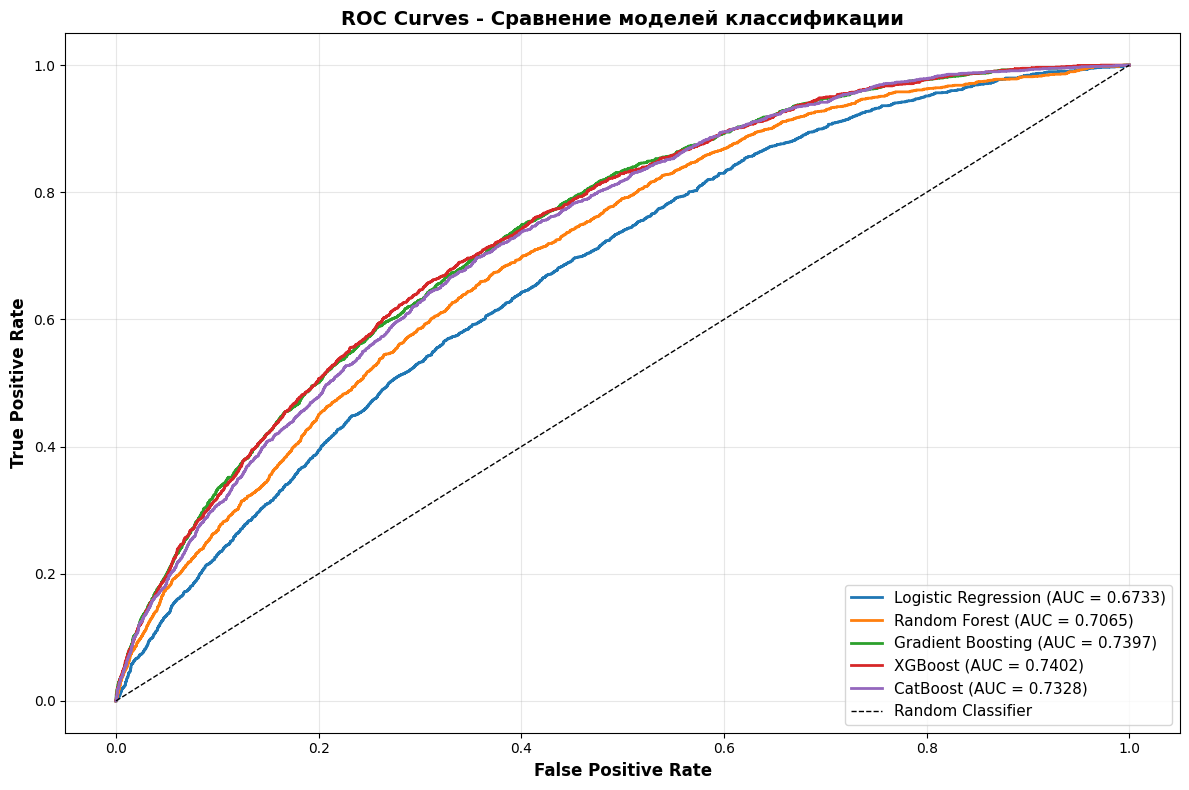


ЯЧЕЙКА 8: АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
✓ График сохранен: feature_importance.png

Топ-15 важных признаков:
   1. Lapse......................... 0.2788
   2. Policies_in_force............. 0.2062
   3. Premium....................... 0.0751
   4. Contract_age.................. 0.0714
   5. Seniority..................... 0.0567
   6. Max_policies.................. 0.0544
   7. Type_risk..................... 0.0483
   8. Area.......................... 0.0435
   9. Power......................... 0.0351
  10. Year_matriculation............ 0.0337
  11. Distribution_channel.......... 0.0303
  12. Driving_experience............ 0.0263
  13. Age........................... 0.0220
  14. Second_driver................. 0.0183


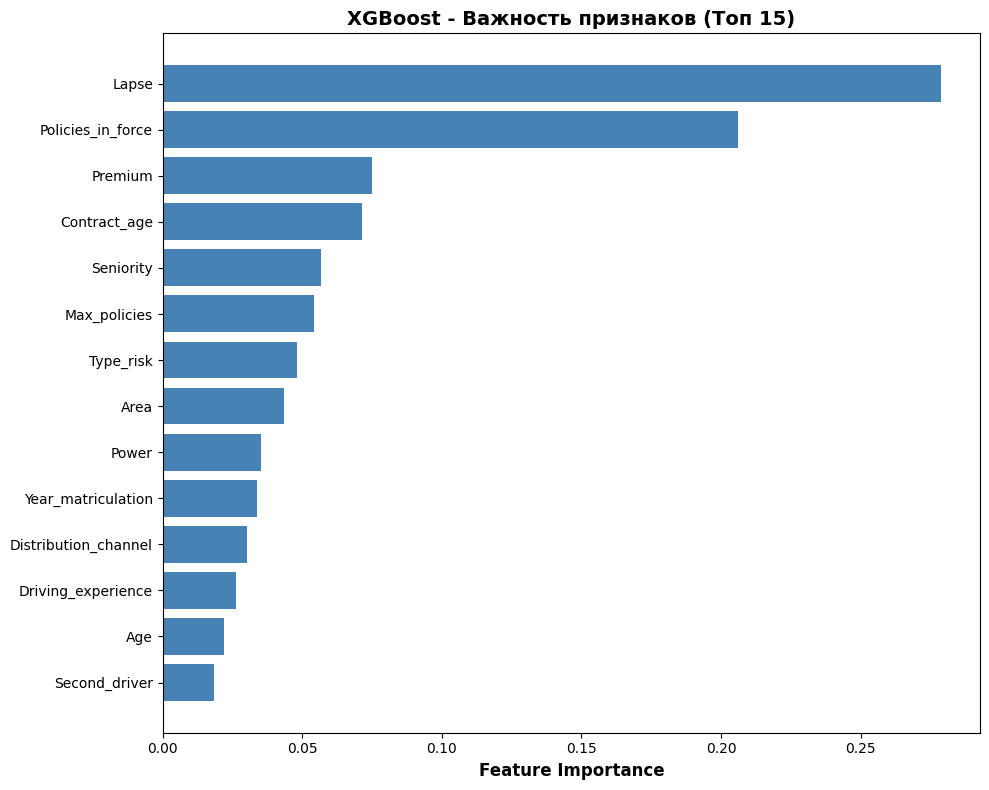

In [55]:
cell_6_cross_validation()
cell_7_plot_roc_curves()
cell_8_plot_feature_importance()


In [56]:
cell_9_ensemble_xgb_catboost()  


ЯЧЕЙКА 9 (НОВАЯ): ENSEMBLE - XGBOOST + CATBOOST ⭐⭐⭐

📊 Получение предсказаний из обеих моделей...
✓ XGBoost вероятности: min=0.0014, max=0.9331, mean=0.4138
✓ CatBoost вероятности: min=0.0129, max=0.9261, mean=0.4311

----------------------------------------------------------------------
СПОСОБ 1: СРЕДНЕЕ (Average Ensemble)
----------------------------------------------------------------------
📈 Результаты Ensemble Average:
  ROC-AUC:   0.7386
  F1-Score:  0.2760
  Precision: 0.1716
  Recall:    0.7051

----------------------------------------------------------------------
СПОСОБ 2: ВЗВЕШЕННОЕ СРЕДНЕЕ (Weighted Average Ensemble)
----------------------------------------------------------------------
📈 Результаты Ensemble Weighted (XGB=0.5, CAT=0.5):
  ROC-AUC:   0.7386
  F1-Score:  0.2760
  Precision: 0.1716
  Recall:    0.7051

----------------------------------------------------------------------
СПОСОБ 3: МАКСИМУМ (Maximum Ensemble)
--------------------------------------------------

{'Ensemble_Average': {'roc_auc': 0.7386077926144264,
  'f1': 0.2759755979471289,
  'precision': 0.1715627257404286,
  'recall': 0.7050964868876793},
 'Ensemble_Weighted': {'roc_auc': 0.7386077926144264,
  'f1': 0.2759755979471289,
  'precision': 0.1715627257404286,
  'recall': 0.7050964868876793},
 'Ensemble_Max': {'roc_auc': 0.7387893203085777,
  'f1': 0.26930303301422565,
  'precision': 0.1643730886850153,
  'recall': 0.7446808510638298}}


ЯЧЕЙКА 10: ROC-КРИВЫЕ ВСЕХ МОДЕЛЕЙ + ENSEMBLE

📊 График 1: Индивидуальные модели
  ✓ Logistic Regression: 0.6733
  ✓ Random Forest: 0.7065
  ✓ Gradient Boosting: 0.7397
  ✓ XGBoost: 0.7402
  ✓ CatBoost: 0.7328

📊 График 2: XGBoost + CatBoost + Ensemble
  ✓ XGBoost: 0.7402
  ✓ CatBoost: 0.7328
  ✓ Ensemble_Average: 0.7386
  ✓ Ensemble_Weighted: 0.7386
  ✓ Ensemble_Max: 0.7388

✓ График сохранен: roc_curves_with_ensemble.png


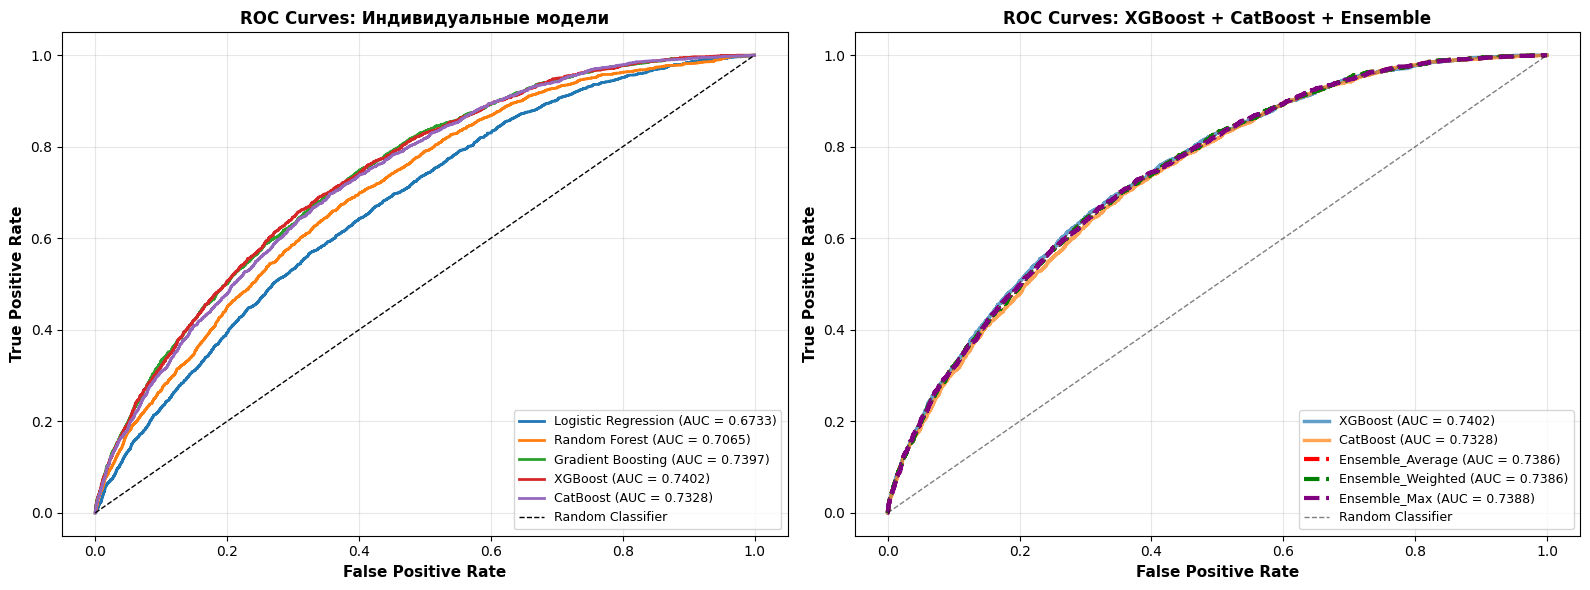


ЯЧЕЙКА 12: ИТОГОВАЯ СВОДКА

🏆 ЛУЧШАЯ ИНДИВИДУАЛЬНАЯ МОДЕЛЬ: XGBoost
   ROC-AUC: 0.7402
   F1-Score: 0.2794

⭐⭐⭐ ЛУЧШАЯ ENSEMBLE МОДЕЛЬ: Ensemble_Max
   ROC-AUC: 0.7388
   F1-Score: 0.2693

📈 Улучшение Ensemble vs Лучшей индивидуальной:
   -0.14% (ROC-AUC)

----------------------------------------------------------------------
ВСЕ РЕЗУЛЬТАТЫ:
----------------------------------------------------------------------

Индивидуальные модели:
  XGBoost............................ ROC-AUC: 0.7402
  Gradient Boosting.................. ROC-AUC: 0.7397
  CatBoost........................... ROC-AUC: 0.7328
  Random Forest...................... ROC-AUC: 0.7065
  Logistic Regression................ ROC-AUC: 0.6733

Ensemble модели:
  Ensemble_Max....................... ROC-AUC: 0.7388
  Ensemble_Average................... ROC-AUC: 0.7386
  Ensemble_Weighted.................. ROC-AUC: 0.7386

РЕКОМЕНДАЦИИ:

✓ Используйте XGBoost для production (если нет Ensemble)
✓ Используйте Ensemble_Max для максим

In [57]:

cell_10_plot_all_roc_curves_with_ensemble()
cell_12_final_summary()